In [ ]:
import pandas as pd
df = pd.read_csv("cirrhosis.csv")
print(df.head())
print(df.info())

   ID  N_Days Status             Drug    Age Sex Ascites Hepatomegaly Spiders  \
0   1     400      D  D-penicillamine  21464   F       Y            Y       Y   
1   2    4500      C  D-penicillamine  20617   F       N            Y       Y   
2   3    1012      D  D-penicillamine  25594   M       N            N       N   
3   4    1925      D  D-penicillamine  19994   F       N            Y       Y   
4   5    1504     CL          Placebo  13918   F       N            Y       Y   

  Edema  Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  \
0     Y       14.5        261.0     2.60   156.0    1718.0  137.95   
1     N        1.1        302.0     4.14    54.0    7394.8  113.52   
2     S        1.4        176.0     3.48   210.0     516.0   96.10   
3     S        1.8        244.0     2.54    64.0    6121.8   60.63   
4     N        3.4        279.0     3.53   143.0     671.0  113.15   

   Tryglicerides  Platelets  Prothrombin  Stage  
0          172.0      190.0         12.2  

In [ ]:
print(df.isnull().sum())

ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64


In [ ]:
print(df.describe())

               ID       N_Days           Age   Bilirubin  Cholesterol  \
count  418.000000   418.000000    418.000000  418.000000   284.000000   
mean   209.500000  1917.782297  18533.351675    3.220813   369.510563   
std    120.810458  1104.672992   3815.845055    4.407506   231.944545   
min      1.000000    41.000000   9598.000000    0.300000   120.000000   
25%    105.250000  1092.750000  15644.500000    0.800000   249.500000   
50%    209.500000  1730.000000  18628.000000    1.400000   309.500000   
75%    313.750000  2613.500000  21272.500000    3.400000   400.000000   
max    418.000000  4795.000000  28650.000000   28.000000  1775.000000   

          Albumin      Copper      Alk_Phos        SGOT  Tryglicerides  \
count  418.000000  310.000000    312.000000  312.000000     282.000000   
mean     3.497440   97.648387   1982.655769  122.556346     124.702128   
std      0.424972   85.613920   2140.388824   56.699525      65.148639   
min      1.960000    4.000000    289.000000   

In [ ]:
import pandas as pd
df = pd.read_csv('cirrhosis.csv')
df['Age_Years'] = df['Age']/365.25 #conversion of age from days to years
df['Age_Years'] = df['Age_Years'].round(1)
print(df['Age_Years'].describe()) #confirmation
df.drop(columns=['Age'],inplace=True) #dropping the original 'Age' column as it is no longer needed

count    418.000000
mean      50.744019
std       10.445328
min       26.300000
25%       42.850000
50%       51.000000
75%       58.275000
max       78.400000
Name: Age_Years, dtype: float64


/tmp/ipython-input-3916426395.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-3916426395.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

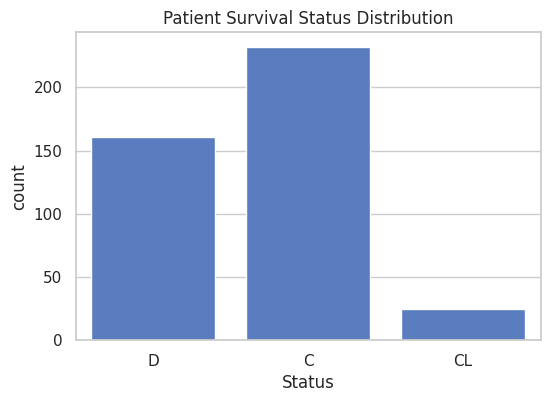

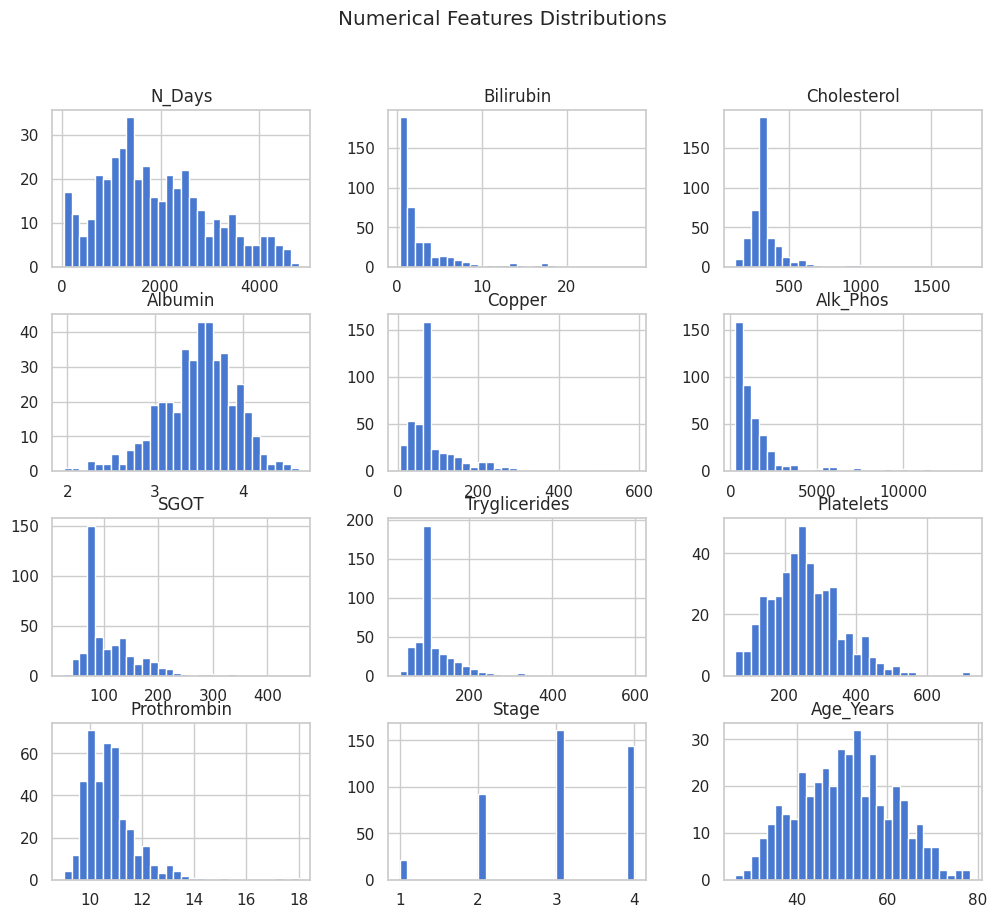

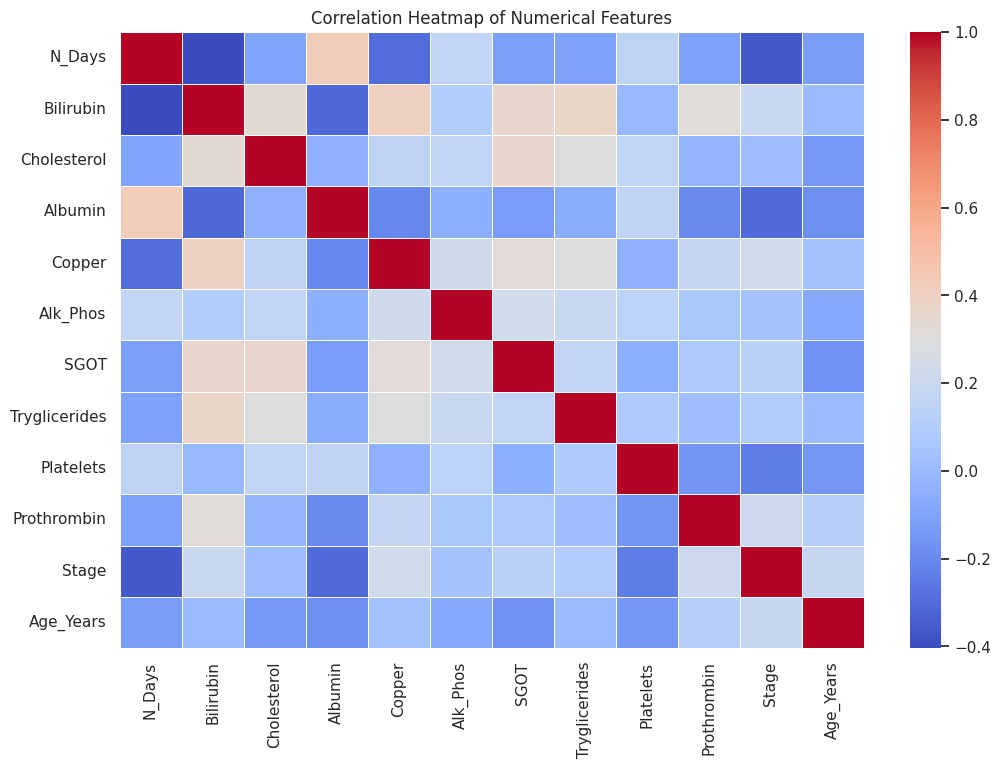

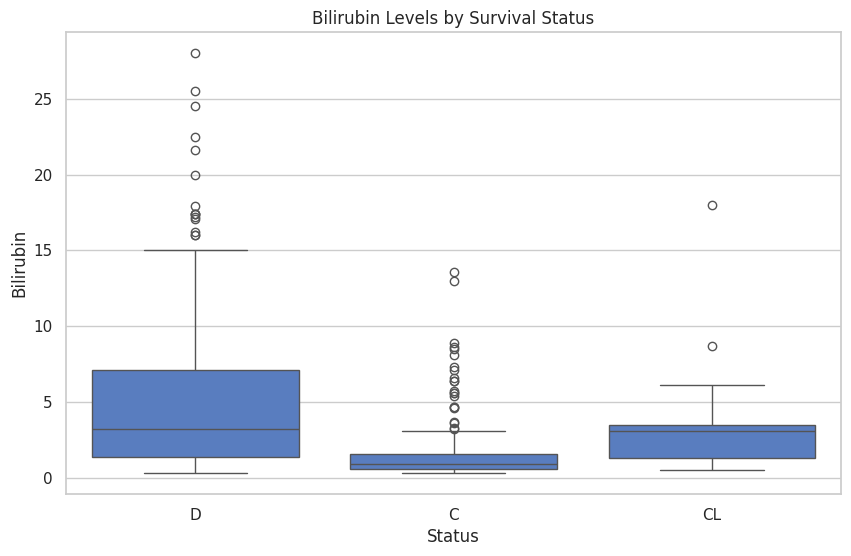

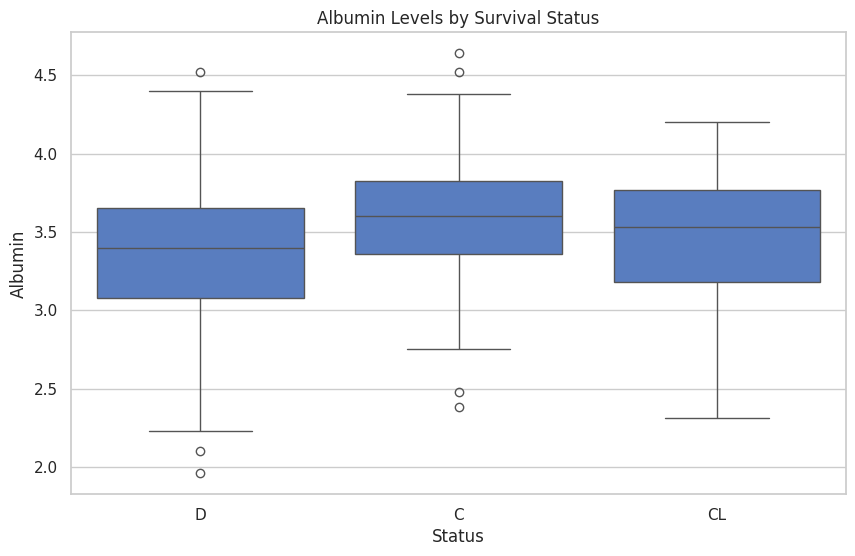

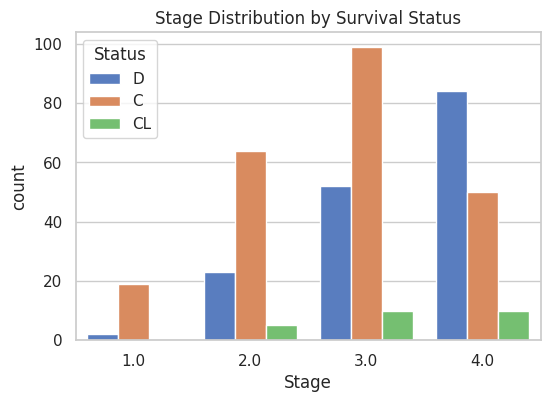

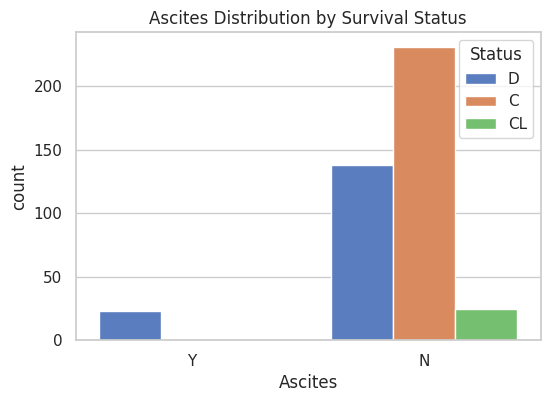

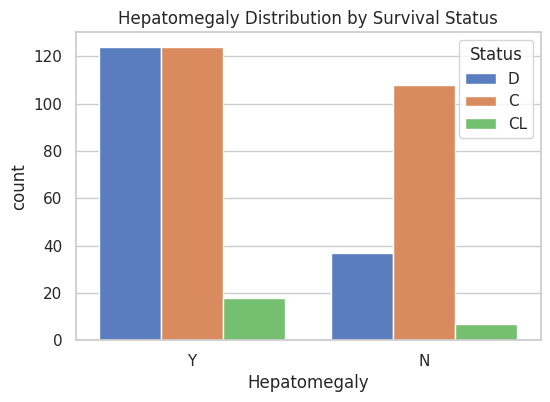

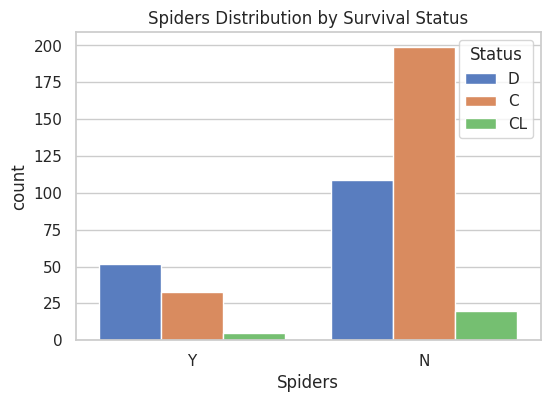

In [ ]:
#for numerical columns
num_cols = ['Platelets', 'Prothrombin', 'Cholesterol', 'Tryglicerides', 'Copper']
for col in num_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

#for categorical columns
cat_cols = ['Stage', 'Ascites', 'Hepatomegaly', 'Spiders', 'Alk_Phos', 'SGOT']
for col in cat_cols:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

df['Drug'] = df['Drug'].fillna("Unknown")
# print(df.isnull().sum()) #final check that shows everything is null
df.drop('ID',axis=1,inplace=True)
# print(df.shape)
# print(df.head())

import seaborn as sns
import matplotlib.pyplot as plt

# PERFORMING EDA TO UNDERSTAND RELATIONSHIPS:
# Patient Survival Status (Censored C or Deceased D):
sns.set(style="whitegrid", palette="muted")
plt.figure(figsize=(6,4))
sns.countplot(x='Status', data=df)
plt.title("Patient Survival Status Distribution")
plt.show()

# Numerical Features Distribution using Histogram
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols].hist(figsize=(12,10), bins=30)
plt.suptitle("Numerical Features Distributions")
plt.show()
#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=False,cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

#Boxplot to find out status of patients with varying protein levels
plt.figure(figsize=(10,6))
sns.boxplot(x='Status', y='Bilirubin',data=df)
plt.title("Bilirubin Levels by Survival Status")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='Status', y='Albumin', data=df)
plt.title("Albumin Levels by Survival Status")
plt.show()

#Categorical Features Analysis
cat_cols = ['Stage', 'Ascites', 'Hepatomegaly', 'Spiders']
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col,hue="Status", data=df)
    plt.title(f"{col} Distribution by Survival Status")
    plt.show()

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0
Support Vector Machine Accuracy: 1.0

Classification Report (Random Forest): 

              precision    recall  f1-score   support

       False       1.00      1.00      1.00        52
        True       1.00      1.00      1.00        32

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



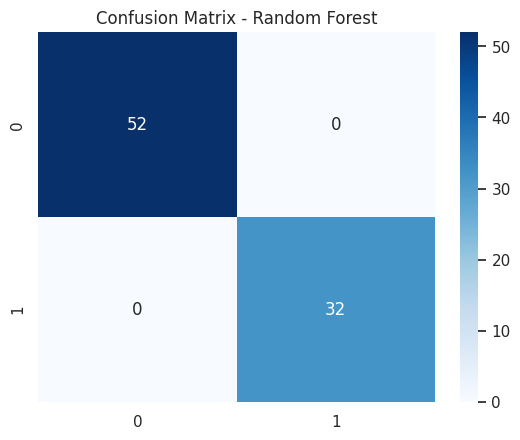

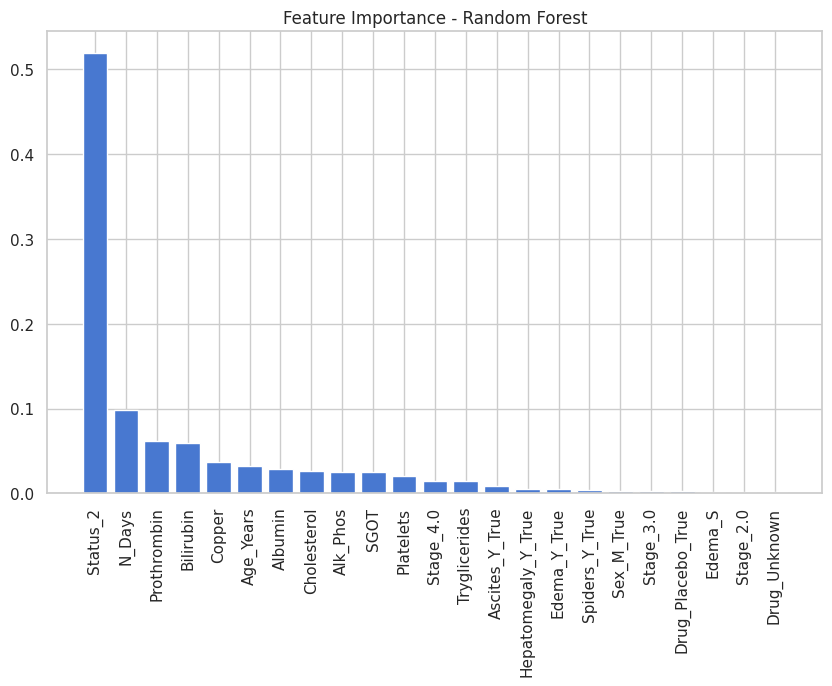

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix


le = LabelEncoder()
df['Status_1'] = le.fit_transform(df['Status_1'])
y = df['Status_2']
x = df.drop('Status_1', axis=1)
cat_cols = ['Stage', 'Hepatomegaly_Y', 'Spiders_Y', 'Drug_Placebo', 'Sex_M', 'Ascites_Y', 'Edema_Y']
x = pd.get_dummies(x, columns=cat_cols, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

#Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#Support Vector Machine
svc = SVC(kernel="rbf", probability=True)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

#Evaluating models
print("Logistic Regression Accuracy:", accuracy_score(y_test,y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test,y_pred_rf))
print("Support Vector Machine Accuracy:", accuracy_score(y_test,y_pred_svc))
print("\nClassification Report (Random Forest): \n")
print(classification_report(y_test, y_pred_rf))
#Actual vs Predicted Values
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

import numpy as np
#which features mattered the most?
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.bar(range(x.shape[1]), importances[indices], align="center")
plt.xticks(range(x.shape[1]), x.columns[indices], rotation=90)
plt.title("Feature Importance - Random Forest")
plt.show()

In [ ]:
print(df.columns.tolist())

['N_Days', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Age_Years', 'Status_1', 'Status_2', 'Hepatomegaly_Y', 'Spiders_Y', 'Drug_Placebo', 'Drug_Unknown', 'Sex_M', 'Ascites_Y', 'Edema_S', 'Edema_Y']
